In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df=pd.read_csv(r"C:\Users\anant\Downloads\archive\Titanic-Dataset.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (891, 12)


In [7]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
# Fill missing values
df['Age'].fillna(df['Age'].mean(), inplace=True) 

C:\Users\anant\AppData\Local\Temp\ipykernel_29316\2023064260.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [9]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
print("\n--- Statistical Summary ---")
print(df.describe(include='all'))


--- Statistical Summary ---
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1   577   
mean     446.000000    0.383838    2.308642                      NaN   NaN   
std      257.353842    0.486592    0.836071                      NaN   NaN   
min        1.000000    0.000000    1.000000                      NaN   NaN   
25%      223.500000    0.000000    2.000000                      NaN   NaN   
50%      446.000000    0.000000    3.000000                      NaN   NaN   
75%      668.500000    1.000000    3.000000                      NaN   NaN   
max      891.000000    1.000000    3.000000                      NaN   NaN   

               Age       SibSp    

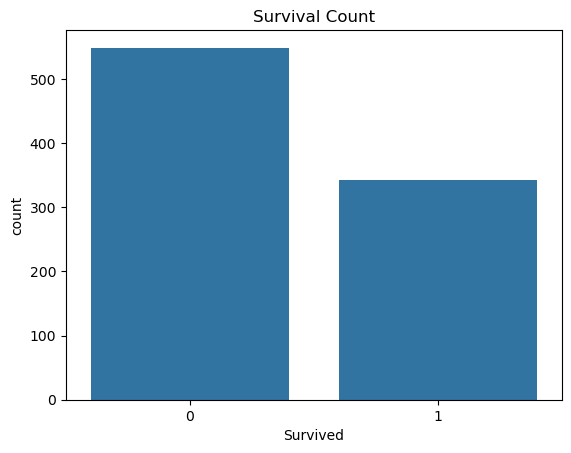

In [11]:
# Countplot for target (if 'Survived' exists)
if 'Survived' in df.columns:
    sns.countplot(data=df, x='Survived')
    plt.title("Survival Count")
    plt.show()

In [12]:

# Remove duplicate rows
df = df.drop_duplicates()

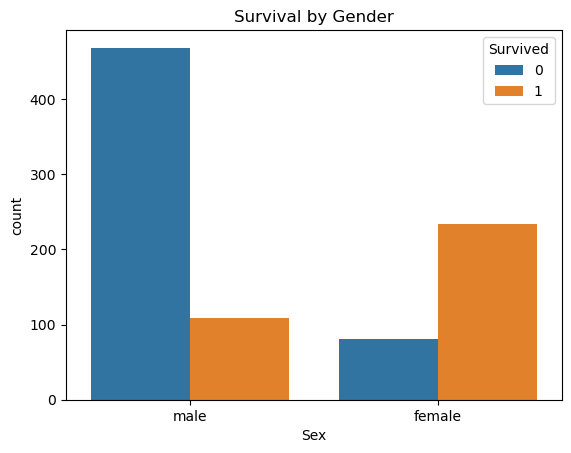

In [21]:
# Example: Survival by gender
if {'Sex', 'Survived'}.issubset(df.columns):
    sns.countplot(data=df, x='Sex', hue='Survived')
    plt.title("Survival by Gender")
    plt.show()

In [24]:
# Check data type of a Pclass 
print(df['Pclass'].dtypes)

int64


In [27]:
print(df['Survived'].dtypes)

int64


In [29]:
print(df['Age'].dtypes)

float64


In [31]:
# Convert categorical → numeric using Label Encoding (SEX)
label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col])

In [33]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.000000,1,0,523,7.2500,147,2
1,2,1,1,190,0,38.000000,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.000000,0,0,669,7.9250,147,2
3,4,1,1,272,0,35.000000,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.000000,0,0,472,8.0500,147,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,548,1,27.000000,0,0,101,13.0000,147,2
887,888,1,1,303,0,19.000000,0,0,14,30.0000,30,2
888,889,0,3,413,0,29.699118,1,2,675,23.4500,147,2
889,890,1,1,81,1,26.000000,0,0,8,30.0000,60,0


In [35]:
# Define features and target
X = df[['Age', 'Pclass', 'Sex']]
y = df['Survived']

In [37]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# Feature scaling (optional but recommended)
# ------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
# Train logistic regression model
# ------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [43]:
# ------------------------
#  Make predictions
# ------------------------
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1], dtype=int64)

In [45]:
#  Evaluate the model
# ------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877
Confusion Matrix:
 [[91 14]
 [20 54]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [47]:
# 91 passengers correctly predicted as not survived.

# 54 passengers correctly predicted as survived.

# 14 false positives → predicted “survived” but actually didn’t.

# 20 false negatives → predicted “not survived” but actually survived.

In [49]:
# our model provide total of 34 wrong predictions so we are going to plot the ROC AUC curve

In [51]:
# Count of alive (survived) and dead (not survived)
count = df['Survived'].value_counts()

print(count)

Survived
0    549
1    342
Name: count, dtype: int64


In [91]:
X_test

array([[ 0.01239022,  0.81303367,  0.7243102 ],
       [ 0.11257046, -0.40055118,  0.7243102 ],
       [-0.73453348,  0.81303367,  0.7243102 ],
       [-1.81266577, -0.40055118, -1.38062393],
       [-1.19659018,  0.81303367, -1.38062393],
       [-0.27247679, -1.61413602, -1.38062393],
       [ 0.01239022,  0.81303367, -1.38062393],
       [-1.04257128,  0.81303367,  0.7243102 ],
       [-1.04257128,  0.81303367, -1.38062393],
       [-0.81154293, -1.61413602, -1.38062393],
       [ 0.57462715, -1.61413602,  0.7243102 ],
       [ 1.1136933 ,  0.81303367,  0.7243102 ],
       [ 0.01239022,  0.81303367, -1.38062393],
       [ 0.03556101,  0.81303367,  0.7243102 ],
       [ 0.49761771, -0.40055118,  0.7243102 ],
       [-1.04257128, -1.61413602, -1.38062393],
       [ 0.9596744 , -1.61413602,  0.7243102 ],
       [ 0.01239022,  0.81303367, -1.38062393],
       [-0.19546734, -0.40055118,  0.7243102 ],
       [ 1.34472165, -1.61413602,  0.7243102 ],
       [-0.42649569,  0.81303367,  0.724

In [129]:
# here data imbalance occured

In [131]:
#here y_pred_proba is the probability od xtest values

In [133]:
y_pred_proba = model.predict_proba(X_test)[:, 1] 
y_pred_proba

array([0.09418543, 0.22311905, 0.11783665, 0.87557866, 0.66708219,
       0.92303184, 0.5718907 , 0.12900634, 0.65551378, 0.93493287,
       0.41266614, 0.06705042, 0.5718907 , 0.09352457, 0.2015375 ,
       0.93949029, 0.3817598 , 0.5718907 , 0.24153598, 0.35178179,
       0.10751468, 0.43156325, 0.63781351, 0.11783665, 0.09418543,
       0.14744078, 0.39402293, 0.22311905, 0.16800132, 0.56364599,
       0.12054792, 0.61973136, 0.45899217, 0.5718907 , 0.12331285,
       0.10030311, 0.46990669, 0.5718907 , 0.91536439, 0.09418543,
       0.27104644, 0.09573716, 0.09418543, 0.09418543, 0.473626  ,
       0.12900634, 0.12054792, 0.11001808, 0.10751468, 0.29001642,
       0.71655832, 0.85969888, 0.07380888, 0.57896503, 0.04010757,
       0.93648642, 0.21867444, 0.86581404, 0.76892517, 0.63781351,
       0.11517837, 0.85451089, 0.79947804, 0.45899217, 0.09418543,
       0.65341312, 0.27104644, 0.09573716, 0.12613211, 0.85969888,
       0.80763066, 0.93648642, 0.48279017, 0.89553147, 0.11001

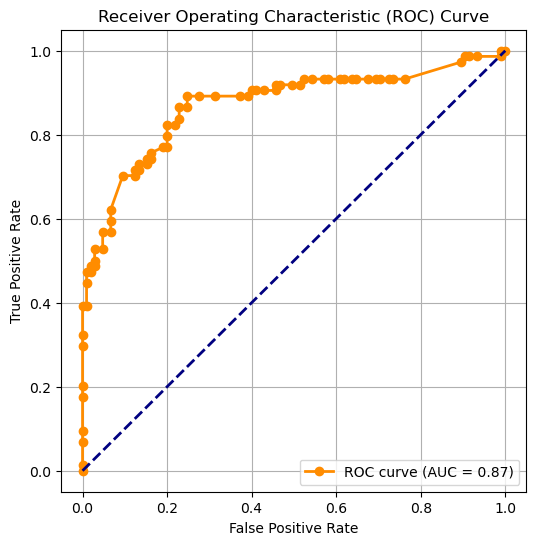

In [135]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})',marker='o')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [137]:
print(thresholds)

[       inf 0.93949029 0.93493287 0.92303184 0.91596446 0.91536439
 0.86581404 0.85969888 0.8218165  0.80763066 0.76892517 0.76430455
 0.75487308 0.74519001 0.7250829  0.72177422 0.71655832 0.69511624
 0.65551378 0.64375806 0.63781351 0.57896503 0.5718907  0.55728396
 0.51878846 0.51233826 0.50215299 0.49569656 0.48279017 0.473626
 0.46990669 0.45899217 0.45435927 0.42523919 0.41893951 0.40642101
 0.39402293 0.3817598  0.35178179 0.3400955  0.27432617 0.26096245
 0.22762767 0.22599864 0.22311905 0.21867444 0.2015375  0.16800132
 0.15071683 0.14744078 0.12900634 0.12613211 0.12331285 0.12054792
 0.11783665 0.11650093 0.11517837 0.11257241 0.11001808 0.10876006
 0.10751468 0.10506153 0.10419132 0.10030311 0.09799644 0.09573716
 0.09418543 0.09352457 0.09243556 0.08313682 0.06705042 0.06545283
 0.04010757]


In [139]:
# Create DataFrame
roc_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr,
    'Thresholds': thresholds
})

# Display first few rows
print(roc_df.head())

   False_Positive_Rate  True_Positive_Rate  Thresholds
0                  0.0            0.000000         inf
1                  0.0            0.013514    0.939490
2                  0.0            0.067568    0.934933
3                  0.0            0.094595    0.923032
4                  0.0            0.175676    0.915964


In [141]:
roc_df

,False_Positive_Rate,True_Positive_Rate,Thresholds
0,0.000000,0.000000,inf
1,0.000000,0.013514,0.939490
2,0.000000,0.067568,0.934933
3,0.000000,0.094595,0.923032
4,0.000000,0.175676,0.915964
...,...,...,...
68,0.914286,0.986486,0.092436
69,0.933333,0.986486,0.083137
70,0.990476,0.986486,0.067050
71,0.990476,1.000000,0.065453


Optimal Threshold: 0.3817598042209666
True Positive Rate: 0.8648648648648649
False Positive Rate: 0.22857142857142856


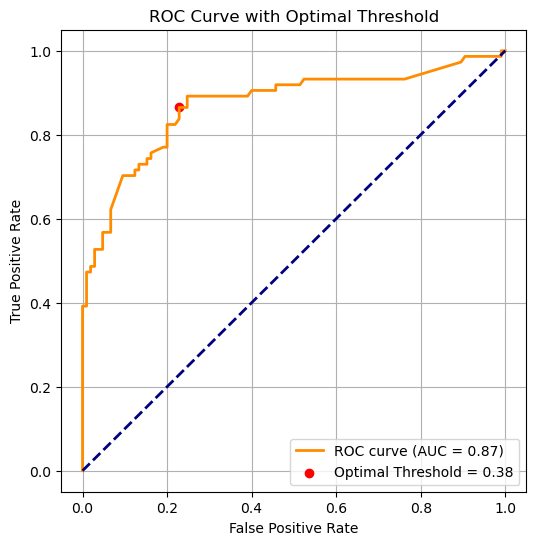

In [143]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Assuming y_test (actual) and y_pred_proba (predicted probabilities) are ready
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Compute the distance to top-left corner (0,1)
distances = np.sqrt((1 - tpr)**2 + (fpr)**2)

# Find index of the smallest distance
optimal_idx = np.argmin(distances)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)
print("True Positive Rate:", tpr[optimal_idx])
print("False Positive Rate:", fpr[optimal_idx])

# Plot ROC curve with the optimal point
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Mark the optimal point
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Optimal Threshold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [145]:
# y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of Survived=1
threshold = 0.3 # your chosen threshold

# Apply threshold to get final predictions
y_pred_custom = np.where(y_pred_proba >= threshold, 1, 0)

# Optional: evaluate performance
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_custom)
cr = classification_report(y_test, y_pred_custom)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)


Confusion Matrix:
 [[78 27]
 [ 8 66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.82       105
           1       0.71      0.89      0.79        74

    accuracy                           0.80       179
   macro avg       0.81      0.82      0.80       179
weighted avg       0.83      0.80      0.81       179



In [1]:
# here model accuracy is increased my adjusting the threshold.
# to get the threshold i use y_pred_proba of the corresponding X train values 
#from this i plot ROC AUC curve then from the y axis (tpr) i got the threshold point
# and by adjusting this threshold i can increase the accuracy of the model